# Objective 2 روی مدل واقعی پروژه — با کد قابل‌ادغام با Objective 1

این نوت‌بوک، Objective 2 (منحنی حساسیت ۵-نقطه‌ای + تخصیص بیت با MCKP) رو دقیقاً هم‌راستا با `Quant_Baseline.ipynb` شما پیاده می‌کنه: از همون مدل (`unsloth/Llama-3.2-1B-Instruct`)، همون calibration dataset (`open_platypus`) و همون الگوی بارگذاری استفاده می‌کنه، تا نتایج AP-Quant مستقیماً با GPTQ/AWQ آن‌جا قابل‌مقایسه باشه.

**یک نکته که موقع خوندن `Quant_Baseline.ipynb` دیدم:** توی `Config` شما، `model_id` این‌طور نوشته شده: `"unsloth/llama-3.2-1b-Instruct"` (با حروف کوچیک). ریپازیتوری واقعی روی HuggingFace با حروف بزرگ ثبت شده: `unsloth/Llama-3.2-1B-Instruct`. چون شناسه‌های HuggingFace به حروف بزرگ/کوچیک حساسن، این احتمالاً هنگام بارگذاری با ارور 404 مواجه می‌شه — بهتره اینجا و توی baseline هر دو اصلاحش کنید (من پایین از نسخه‌ی درست استفاده کردم).

**ساختار کد:** به‌جای اینکه همه‌چیز رو داخل سلول‌های نوت‌بوک بریزم، دو فایل پایتون واقعی (`ap_quant_common.py` و `objective2.py`) می‌سازم — این‌ها همون فایل‌هایی هستن که بالا هم به‌صورت مجزا آپلود کردم تا مستقیم به ریپو اضافه کنید. نوت‌بوک با دستور `%%writefile` اول این‌ها رو روی دیسک می‌سازه، بعد ازشون import می‌کنه — یعنی هم توی Colab سرراست اجرا می‌شه، هم فایل‌های تمیز و قابل‌merge برای وقتی که کد Objective 1 همکارتون آماده شد دارید.

**صادقانه:** الگوریتم `solve_mckp` رو با ۴۰۰+ نمونه‌ی تصادفی در برابر brute-force تست کردم (نتیجه پایین همینه که اجرا می‌کنید). ولی چون اینجا شبکه ندارم، خود مدل ۱ میلیاردی رو نتونستم دانلود کنم و بخش‌های وابسته به مدل واقعی رو خودم اجرا نکردم — این‌ها رو با دقت و طبق pattern دقیق baseline خودتون نوشتم، ولی باید توی Colab خودتون تست بشن.


## ۰. ساخت دو فایل پایتون (`%%writefile`)

این دو سلول، `ap_quant_common.py` (utilities مشترک بین Objective 1 و 2) و `objective2.py` (خود الگوریتم) رو می‌سازن. محتوای این دو فایل دقیقاً همونیه که به‌صورت جدا هم براتون فرستادم.


In [1]:
%%writefile ap_quant_common.py
"""
Shared utilities for AP-Quant -- used by BOTH Objective 1 and Objective 2.

Mirrors the config/calibration conventions of Quant_Baseline.ipynb so that
the GPTQ/AWQ baselines and AP-Quant are calibrated on the *same* data.
Keep this file identical between teammates so P/O/loss are computed the
same way on both sides of the project.
"""
import os
from dataclasses import dataclass, field
from typing import List

import torch
from datasets import load_dataset
from transformers import AutoModelForCausalLM, AutoTokenizer


@dataclass
class Config:
    # --- shared with Quant_Baseline.ipynb: keep these in sync with your teammate ---
    model_id: str = "unsloth/Llama-3.2-1B-Instruct"
    cal_dataset: str = "open_platypus"     # "open_platypus" | "ultrachat" | "c4_small" | "wikitext"
    num_calibration_samples: int = 128      # start small to verify things run; raise to 128 for final numbers
    max_seq_length: int = 512

    # --- Objective 2 specific ---
    candidate_bits: List[int] = field(default_factory=lambda: [2, 3, 4, 8, 16])
    target_avg_bits: int = 4
    lambda_ref_bits: int = 4               # bit-width used once to estimate lambda (eq. 10)
    results_path: str = "objective2_results.json"


def load_model_and_tokenizer(cfg: Config):
    """Same pattern as Quant_Baseline.ipynb, plus attn_implementation='eager'
    (needed so output_attentions actually returns P instead of None)."""
    model = AutoModelForCausalLM.from_pretrained(
        cfg.model_id,
        torch_dtype="auto",
        device_map="auto",
        attn_implementation="eager",
        token=os.environ.get("HF_TOKEN", None),
    ).eval()
    tokenizer = AutoTokenizer.from_pretrained(cfg.model_id)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    return model, tokenizer


def load_calibration_dataset(cfg: Config, tokenizer):
    """Copied from Quant_Baseline.ipynb (same function, same defaults) so AP-Quant
    calibrates on the exact same data as the GPTQ/AWQ baselines. If this changes
    in the baseline notebook, update it here too."""
    if cfg.cal_dataset is None:
        return None

    if cfg.cal_dataset == "open_platypus":
        ds = load_dataset("garage-bAInd/Open-Platypus", split="train")
        ds = ds.shuffle(seed=42).select(range(cfg.num_calibration_samples))

        def to_text(example):
            return {"text": example.get("question", "") + "\n" + example.get("answer", "")}

        ds = ds.map(to_text)

    elif cfg.cal_dataset == "ultrachat":
        ds = load_dataset("HuggingFaceH4/ultrachat_200k", split="train_sft")
        ds = ds.shuffle(seed=42).select(range(cfg.num_calibration_samples))

        def preprocess(example):
            return {"text": tokenizer.apply_chat_template(example["messages"], tokenize=False)}

        ds = ds.map(preprocess)

    elif cfg.cal_dataset == "c4_small":
        ds = load_dataset("brando/small-c4-dataset", split="train")
        ds = ds.shuffle(seed=42).select(range(cfg.num_calibration_samples))

    elif cfg.cal_dataset == "wikitext":
        ds = load_dataset("Salesforce/wikitext", "wikitext-103-raw-v1", split="train")
        ds = ds.shuffle(seed=42).select(range(cfg.num_calibration_samples))

    else:
        raise ValueError(f"Unknown calibration dataset: {cfg.cal_dataset}")

    def tokenize(sample):
        return tokenizer(
            sample["text"], padding=False, max_length=cfg.max_seq_length,
            truncation=True, add_special_tokens=False,
        )

    ds = ds.map(tokenize, remove_columns=[c for c in ds.column_names if c != "input_ids"])
    return ds


def calib_dataset_to_tensors(calib_ds) -> List[torch.Tensor]:
    """Turns the tokenized HF Dataset into a list of (1, seq_len) LongTensors,
    one per calibration example. Skips any example that tokenized to length 0."""
    tensors = []
    for row in calib_ds:
        ids = row["input_ids"]
        if len(ids) == 0:
            continue
        tensors.append(torch.tensor(ids, dtype=torch.long).unsqueeze(0))
    return tensors


@torch.no_grad()
def get_P_and_O(model, input_ids):
    """One forward pass. Returns:
       - P: tuple of attention-probability tensors, one per layer  (== Softmax(S), eq. 3/6)
       - O: dict {layer_idx: tensor}, the input to o_proj           (== P @ V, eq. 3)
    Shared between Objective 1 and Objective 2 -- both must compute P, O the same way.
    """
    captured_O = {}
    hooks = []

    def make_hook(layer_idx):
        def hook(module, inp, out):
            captured_O[layer_idx] = inp[0].detach()
        return hook

    for i, layer in enumerate(model.model.layers):
        hooks.append(layer.self_attn.o_proj.register_forward_hook(make_hook(i)))

    device = next(model.parameters()).device
    out = model(input_ids.to(device), output_attentions=True)

    for h in hooks:
        h.remove()

    return out.attentions, captured_O


def joint_loss(P1, O1, P2, O2, lam, eps=1e-6):
    """Eq. (7)-(9): L_joint = L_output + lambda * L_KL.
    P1,O1 = full-precision reference; P2,O2 = quantized."""
    L_out = (O2 - O1).pow(2).sum() / (O1.pow(2).sum() + eps)
    p1 = P1.clamp(min=1e-9)
    p2 = P2.clamp(min=1e-9)
    L_kl = (p1 * (p1.log() - p2.log())).sum(dim=-1).mean()
    return L_out + lam * L_kl, L_out.item(), L_kl.item()


Writing ap_quant_common.py


In [2]:
%%writefile objective2.py
"""
Objective 2: Full-Curve Sensitivity Allocation (AP-Quant proposal, eq. 11-13).

Measures a 5-point sensitivity curve per attention block, then allocates
bit-widths as a Multiple-Choice Knapsack Problem solved exactly via DP.
No training, no backprop -- everything here is forward passes + a
combinatorial optimizer.

Depends on ap_quant_common.py (same directory).
"""
import json

import torch

from ap_quant_common import (
    Config,
    load_model_and_tokenizer,
    load_calibration_dataset,
    calib_dataset_to_tensors,
    get_P_and_O,
    joint_loss,
)

PROJ_NAMES = ["q_proj", "k_proj", "v_proj"]


def fake_quantize(W, bits, per_channel=True):
    """Symmetric round-to-nearest -- ONLY for measuring sensitivity.
    The learned LSQ quantizer (Objective 1) is a separate, gradient-trained
    module; this one just needs to be a reasonable stand-in so the sensitivity
    ordering across blocks/bit-widths is meaningful."""
    qmax = 2 ** (bits - 1) - 1
    dim = 1 if per_channel else None
    max_val = W.abs().amax(dim=dim, keepdim=per_channel).clamp(min=1e-8)
    delta = max_val / qmax
    return torch.clamp(torch.round(W / delta), -qmax, qmax) * delta


@torch.no_grad()
def cache_reference(model, calib_tensors):
    """Runs the full-precision model once per calibration example and caches
    P, O for every layer. This is the (O, P) that every quantized variant is
    compared against."""
    ref_P, ref_O = [], []
    for ids in calib_tensors:
        P, O = get_P_and_O(model, ids)
        ref_P.append(P)
        ref_O.append(O)
    return ref_P, ref_O


@torch.no_grad()
def _quantize_block(model, layer_idx, bits):
    attn = model.model.layers[layer_idx].self_attn
    orig = {n: getattr(attn, n).weight.data.clone() for n in PROJ_NAMES}
    for n in PROJ_NAMES:
        getattr(attn, n).weight.data = fake_quantize(orig[n], bits=bits)
    return orig


@torch.no_grad()
def _restore_block(model, layer_idx, orig):
    attn = model.model.layers[layer_idx].self_attn
    for n in PROJ_NAMES:
        getattr(attn, n).weight.data = orig[n]


@torch.no_grad()
def measure_block_sensitivity(model, calib_tensors, layer_idx, bits, lam, ref_P, ref_O):
    """Quantizes ONLY q/k/v of `layer_idx` to `bits` (rest of the model stays
    full precision), runs the calibration set, and returns the average joint
    loss for that layer relative to the cached full-precision reference.
    Eq. (12): Li(b)."""
    orig = _quantize_block(model, layer_idx, bits)
    total = 0.0
    for ex, ids in enumerate(calib_tensors):
        P_q, O_q = get_P_and_O(model, ids)
        loss, _, _ = joint_loss(
            ref_P[ex][layer_idx], ref_O[ex][layer_idx],
            P_q[layer_idx], O_q[layer_idx], lam=lam,
        )
        total += loss.item()
    _restore_block(model, layer_idx, orig)
    return total / len(calib_tensors)


@torch.no_grad()
def estimate_lambda(model, calib_tensors, ref_P, ref_O, ref_bits=4):
    """Eq. (10): lambda = mean(L_output) / mean(L_KL), estimated ONCE at a
    reference bit-width and then held fixed for the entire sensitivity table
    -- otherwise L_i(b) values at different b would not be comparable and
    the MCKP allocation would be meaningless."""
    n_layers = len(model.model.layers)
    l_out_sum, l_kl_sum, n = 0.0, 0.0, 0
    for i in range(n_layers):
        orig = _quantize_block(model, i, ref_bits)
        for ex, ids in enumerate(calib_tensors):
            P_q, O_q = get_P_and_O(model, ids)
            _, l_out, l_kl = joint_loss(ref_P[ex][i], ref_O[ex][i], P_q[i], O_q[i], lam=1.0)
            l_out_sum += l_out
            l_kl_sum += l_kl
            n += 1
        _restore_block(model, i, orig)
    return (l_out_sum / n) / max(l_kl_sum / n, 1e-8)


@torch.no_grad()
def build_sensitivity_table(model, calib_tensors, candidate_bits, lam, ref_P, ref_O, verbose=True):
    n_layers = len(model.model.layers)
    sensitivity = {i: {} for i in range(n_layers)}
    for i in range(n_layers):
        for b in candidate_bits:
            sensitivity[i][b] = measure_block_sensitivity(
                model, calib_tensors, i, b, lam, ref_P, ref_O
            )
        if verbose:
            row = ", ".join(f"{b}b={sensitivity[i][b]:.4f}" for b in candidate_bits)
            print(f"layer {i:2d}: {row}")
    return sensitivity


def solve_mckp(sensitivity, cost, budget, candidate_bits):
    """Eq. (13): each block i picks exactly one bit-width from candidate_bits;
    minimize total loss subject to a memory budget. Exact 0/1-choice-per-item
    knapsack via dynamic programming -- O(n * budget * len(candidate_bits))."""
    n = len(sensitivity)
    INF = float("inf")
    dp = [INF] * (budget + 1)
    dp[0] = 0.0
    choice = [[None] * (budget + 1) for _ in range(n)]

    for i in range(n):
        new_dp = [INF] * (budget + 1)
        for c in range(budget + 1):
            if dp[c] == INF:
                continue
            for b in candidate_bits:
                c2 = c + cost[b]
                if c2 <= budget and dp[c] + sensitivity[i][b] < new_dp[c2]:
                    new_dp[c2] = dp[c] + sensitivity[i][b]
                    choice[i][c2] = (b, c)
        dp = new_dp

    best_c = min(range(budget + 1), key=lambda c: dp[c])
    assignment, c = {}, best_c
    for i in reversed(range(n)):
        b, prev_c = choice[i][c]
        assignment[i] = b
        c = prev_c
    return assignment, dp[best_c]


def save_results(path, assignment, sensitivity, lam):
    """Hand-off point for your teammate's Objective 1: this JSON says which
    bit-width each attention block should be trained at."""
    payload = {
        "lambda": lam,
        "bit_assignment": {str(k): v for k, v in assignment.items()},
        "sensitivity_table": {
            str(i): {str(b): v for b, v in bd.items()} for i, bd in sensitivity.items()
        },
    }
    with open(path, "w") as f:
        json.dump(payload, f, indent=2)


def load_results(path):
    with open(path) as f:
        payload = json.load(f)
    assignment = {int(k): v for k, v in payload["bit_assignment"].items()}
    sensitivity = {
        int(i): {int(b): v for b, v in bd.items()} for i, bd in payload["sensitivity_table"].items()
    }
    return assignment, sensitivity, payload["lambda"]


def run_objective2(cfg: Config):
    """End-to-end: load model -> load calibration data -> estimate lambda ->
    build the 5-point sensitivity curve -> solve MCKP -> save results."""
    model, tokenizer = load_model_and_tokenizer(cfg)
    calib_ds = load_calibration_dataset(cfg, tokenizer)
    calib_tensors = calib_dataset_to_tensors(calib_ds)
    print(f"{len(calib_tensors)} calibration examples loaded from '{cfg.cal_dataset}'")

    n_layers = len(model.model.layers)
    ref_P, ref_O = cache_reference(model, calib_tensors)

    lam = estimate_lambda(model, calib_tensors, ref_P, ref_O, ref_bits=cfg.lambda_ref_bits)
    print(f"estimated lambda = {lam:.4f}")

    sensitivity = build_sensitivity_table(
        model, calib_tensors, cfg.candidate_bits, lam, ref_P, ref_O
    )

    cost = {b: b for b in cfg.candidate_bits}
    budget = cfg.target_avg_bits * n_layers
    assignment, total_loss = solve_mckp(sensitivity, cost, budget, cfg.candidate_bits)
    achieved_avg = sum(cost[assignment[i]] for i in range(n_layers)) / n_layers
    print(f"total joint loss at this budget: {total_loss:.4f}")
    print(f"achieved average bit-width: {achieved_avg:.2f} (target: {cfg.target_avg_bits})")

    save_results(cfg.results_path, assignment, sensitivity, lam)
    print(f"saved bit assignment + sensitivity table -> {cfg.results_path}")
    return assignment, sensitivity, lam


if __name__ == "__main__":
    run_objective2(Config())


Writing objective2.py


## ۱. تست‌های صحت (بدون نیاز به دانلود مدل)

قبل از صرف زمان روی دانلود مدل ۱ میلیاردی، سه تابع اصلی رو با داده‌ی synthetic چک می‌کنیم — این سلول فقط به torch نیاز داره، نه به مدل واقعی، پس سریع اجرا می‌شه.


In [3]:
import torch
import random
from itertools import product

from ap_quant_common import joint_loss
from objective2 import fake_quantize, solve_mckp

# --- fake_quantize: خطا باید با افزایش بیت‌عرض یکنواخت کم بشه ---
_W = torch.randn(32, 32)
_errs = {b: ((_W - fake_quantize(_W, b)) ** 2).mean().item() for b in [2, 3, 4, 8, 16]}
assert _errs[2] > _errs[4] > _errs[8] > _errs[16] and _errs[16] < 1e-6
print("[OK] fake_quantize:", {k: round(v, 6) for k, v in _errs.items()})

# --- joint_loss: وقتی P2==P1 و O2==O1 باشه، باید صفر بشه ---
_P = torch.softmax(torch.randn(2, 5, 5), dim=-1)
_O = torch.randn(2, 5, 8)
_loss0, _, _ = joint_loss(_P, _O, _P.clone(), _O.clone(), lam=1.0)
assert _loss0.item() < 1e-8
print(f"[OK] joint_loss(P,O,P,O) = {_loss0.item():.2e}")

# --- solve_mckp: مقایسه با brute-force روی نمونه‌های تصادفی ---
random.seed(0)
mismatches = 0
for _ in range(200):
    n = random.randint(2, 6)
    bits = [2, 3, 4, 8, 16]
    cost = {b: b for b in bits}
    sens = {i: {b: round(random.uniform(0.01, 5.0) / b, 3) for b in bits} for i in range(n)}
    budget = random.randint(min(bits) * n, max(bits) * n)
    best = min((sum(sens[i][c[i]] for i in range(n))
                for c in product(bits, repeat=n) if sum(cost[b] for b in c) <= budget),
               default=float("inf"))
    _, dp_loss = solve_mckp(sens, cost, budget, bits)
    if not ((dp_loss == float("inf") and best == float("inf")) or abs(dp_loss - best) < 1e-9):
        mismatches += 1
assert mismatches == 0
print(f"[OK] solve_mckp matched brute-force on 200/200 random trials")


[OK] fake_quantize: {2: 0.464416, 3: 0.049714, 4: 0.009114, 8: 2.9e-05, 16: 0.0}
[OK] joint_loss(P,O,P,O) = 0.00e+00
[OK] solve_mckp matched brute-force on 200/200 random trials


## ۲. تنظیمات (`Config`)

فیلدهای `model_id`, `cal_dataset`, `num_calibration_samples`, `max_seq_length` عیناً معادل همون‌هایی هستن که در `Quant_Baseline.ipynb` دارید — همون مقادیر رو نگه دارید تا calibration data بین AP-Quant و baselineهای GPTQ/AWQ یکی بمونه.

برای اولین اجرا، `num_calibration_samples` رو کم گذاشتم (۱۶) تا سریع تست بشه و باگ‌ها زود پیدا بشن؛ برای عدد نهایی گزارش، بذاریدش ۱۲۸ (مثل baseline).

اگه مدلتون به‌جای Llama-3.2، GPT-2 بود (یکی از گزینه‌های comment-شده در `Config` شما)، این کد کار نمی‌کرد — چون GPT-2 به‌جای `q_proj/k_proj/v_proj` جدا، یک `c_attn` واحد داره. با Llama یا Qwen مشکلی نیست.


In [4]:
from ap_quant_common import Config

cfg = Config(
    model_id="unsloth/Llama-3.2-1B-Instruct",   # به‌جای نسخه‌ی حروف‌کوچیکِ baseline
    cal_dataset="open_platypus",
    num_calibration_samples=16,                  # برای تست اولیه؛ برای عدد نهایی: 128
    max_seq_length=512,
    candidate_bits=[2, 3, 4, 8, 16],
    target_avg_bits=4,
    lambda_ref_bits=4,
    results_path="objective2_results.json",
)
print(cfg)


Config(model_id='unsloth/Llama-3.2-1B-Instruct', cal_dataset='open_platypus', num_calibration_samples=16, max_seq_length=512, candidate_bits=[2, 3, 4, 8, 16], target_avg_bits=4, lambda_ref_bits=4, results_path='objective2_results.json')


## ۳. اجرای کامل

`run_objective2` همه‌چیز رو انجام می‌ده: بارگذاری مدل + tokenizer، بارگذاری calibration set، تخمین $\lambda$ (معادله ۱۰)، ساخت جدول حساسیت (معادله ۱۲)، و حل MCKP (معادله ۱۳). نتیجه هم در `objective2_results.json` ذخیره می‌شه — همین فایل نقطه‌ی وصل‌شدن به کار همکارتونه.

⏱ هزینه: تقریباً `n_layers × 5 × num_calibration_samples` فوروارد‌پس. با تنظیمات پیش‌فرض بالا (۱۶ لایه‌ی احتمالی × ۵ بیت‌عرض × ۱۶ نمونه ≈ ۱۲۸۰ فوروارد‌پس روی یک مدل ۱B) — روی GPU چند دقیقه، روی CPU بیشتر طول می‌کشه.


In [5]:
from objective2 import run_objective2

assignment, sensitivity, lam = run_objective2(cfg)

print("\nbit assignment per layer:")
for i, b in assignment.items():
    print(f"  layer {i:2d}: {b}-bit")


config.json:   0%|          | 0.00/894 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 2.47GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

...

data/train-00000-of-00001-4fe2df04669d16(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/24926 [00:00<?, ? examples/s]

Map:   0%|          | 0/16 [00:00<?, ? examples/s]

Map:   0%|          | 0/16 [00:00<?, ? examples/s]

16 calibration examples loaded from 'open_platypus'
estimated lambda = 6545257.5684
layer  0: 2b=0.7383, 3b=0.2021, 4b=0.0461, 8b=0.0002, 16b=0.0000
layer  1: 2b=0.7656, 3b=0.2119, 4b=0.0737, 8b=0.0005, 16b=0.0000
layer  2: 2b=0.4043, 3b=0.2158, 4b=0.0825, 8b=0.0003, 16b=0.0000
layer  3: 2b=0.5664, 3b=0.2402, 4b=0.1006, 8b=0.0004, 16b=0.0000
layer  4: 2b=0.1777, 3b=0.0732, 4b=0.0466, 8b=0.0002, 16b=0.0000
layer  5: 2b=0.2012, 3b=0.0947, 4b=0.0258, 8b=0.0001, 16b=0.0000
layer  6: 2b=0.1162, 3b=0.0542, 4b=0.0249, 8b=0.0001, 16b=0.0000
layer  7: 2b=0.1768, 3b=0.0640, 4b=0.0220, 8b=0.0001, 16b=0.0000
layer  8: 2b=0.2832, 3b=0.0967, 4b=0.0254, 8b=0.0001, 16b=0.0000
layer  9: 2b=0.2793, 3b=0.0854, 4b=0.0388, 8b=0.0002, 16b=0.0000
layer 10: 2b=0.2520, 3b=0.1030, 4b=0.0386, 8b=0.0002, 16b=0.0000
layer 11: 2b=0.5469, 3b=0.1216, 4b=0.0544, 8b=0.0002, 16b=0.0000
layer 12: 2b=0.4492, 3b=0.1211, 4b=0.0488, 8b=0.0002, 16b=0.0000
layer 13: 2b=0.4785, 3b=0.1680, 4b=0.0645, 8b=0.0003, 16b=0.0000
layer 

## ۴. نمودار تفسیرپذیری: $AP_i = L_i(2) - L_i(16)$


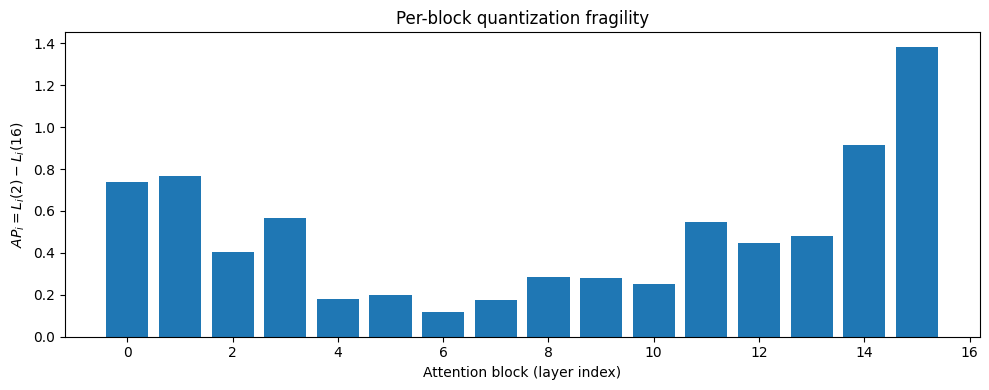

In [6]:
import matplotlib.pyplot as plt

AP = {i: sensitivity[i][2] - sensitivity[i][16] for i in sensitivity}

plt.figure(figsize=(10, 4))
plt.bar(list(AP.keys()), list(AP.values()))
plt.xlabel("Attention block (layer index)")
plt.ylabel(r"$AP_i = L_i(2) - L_i(16)$")
plt.title("Per-block quantization fragility")
plt.tight_layout()
plt.show()


## جمع‌بندی: نقطه‌ی ادغام با Objective 1 و قدم بعدی برای مقاله

- **خروجی این بخش برای همکارتون:** فایل `objective2_results.json` شامل `bit_assignment` (بیت‌عرض هر بلوک)، `sensitivity_table` کامل، و `lambda` است. کد Objective 1 باید همین `bit_assignment` رو به‌عنوان بیت‌عرض *ثابت* هر بلوک بگیره و طبق قدم ۵ الگوریتم پروپوزال، فقط $\Delta$ها رو با `joint_loss` (که در `ap_quant_common.py` است — دقیقاً همون تابعی که همکارتون هم باید استفاده کنه) fine-tune کنه.
- **برای مقاله:** بعد از اینکه Objective 1 هم آماده شد، برای ارزیابی نهایی می‌تونید از `compute_ppl` که در `Quant_Baseline.ipynb` دارید مستقیم استفاده کنید — کافیه مدل نهایی AP-Quant (بعد از quantize کردن واقعی هر لایه در بیت‌عرض تخصیص‌یافته‌اش) رو به همون تابع بدید و با GPTQ/AWQ مقایسه کنید.
- **پیش از عدد نهایی:** `num_calibration_samples` رو به ۱۲۸ برگردونید (مثل baseline) تا نتایج قابل‌گزارش باشن.
